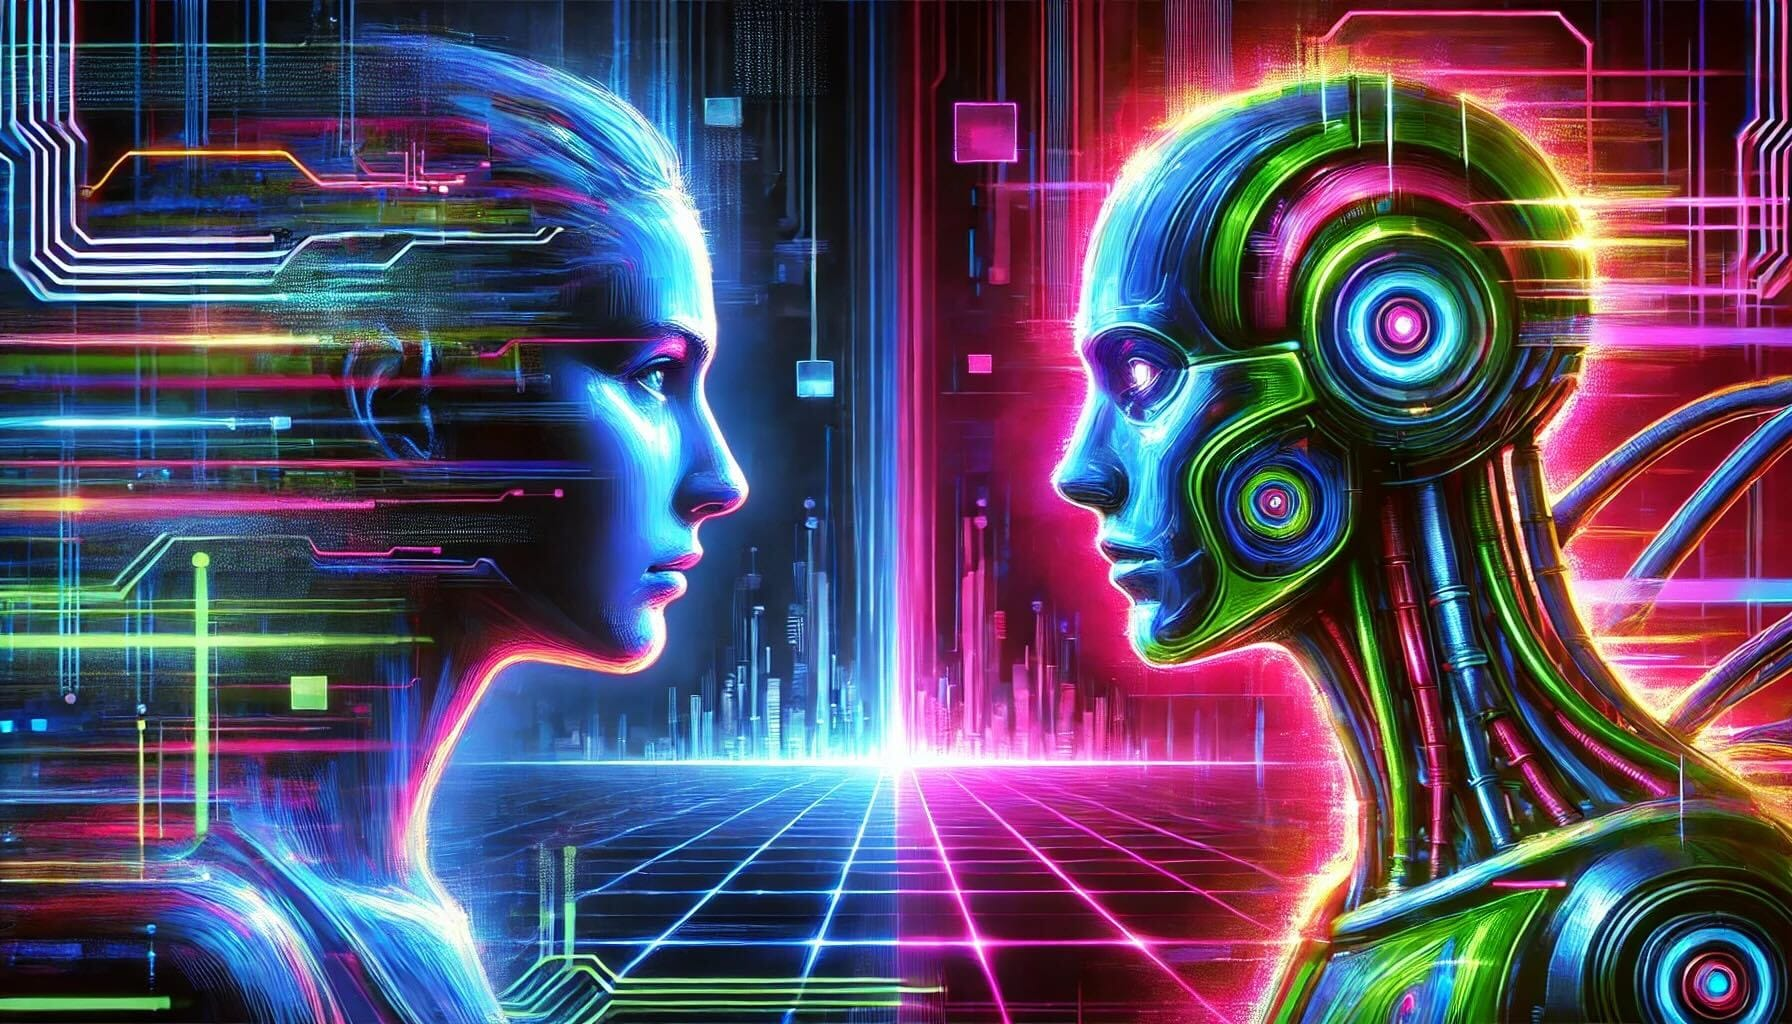

In [12]:
from IPython.display import Image, display

# reading image
display(Image(filename='ai_image.jpg'))

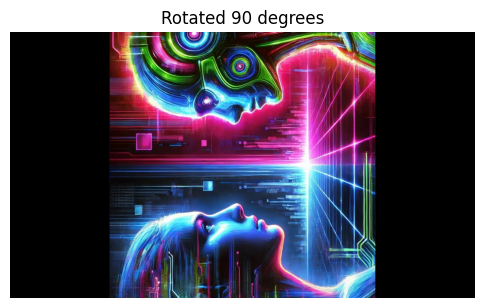

In [19]:
from PIL import Image
import matplotlib.pyplot as plt

# rotation 1
img = Image.open('ai_image.jpg')
rotated = img.rotate(90, expand=False)
plt.figure(figsize=(6,6))
plt.imshow(rotated)
plt.title('Rotated 90 degrees')
plt.axis('off')
plt.show()

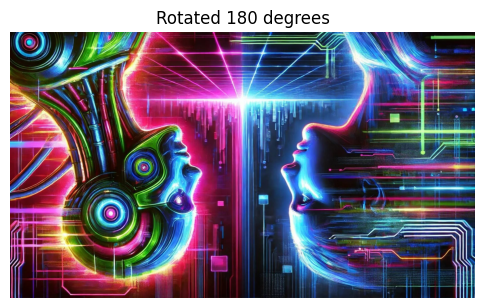

In [18]:
# rotation 2
rotated = img.rotate(180, expand=True)
plt.figure(figsize=(6,6))
plt.imshow(rotated)
plt.title('Rotated 180 degrees')
plt.axis('off')
plt.show()

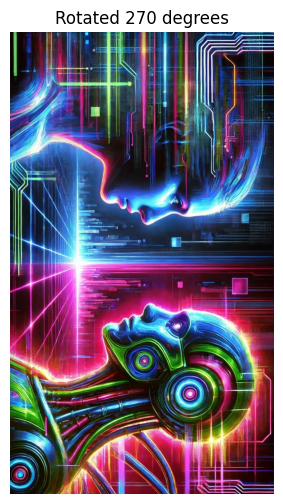

In [15]:
# rotation 3
rotated = img.rotate(270, expand=True)
plt.figure(figsize=(6,6))
plt.imshow(rotated)
plt.title('Rotated 270 degrees')
plt.axis('off')
plt.show()

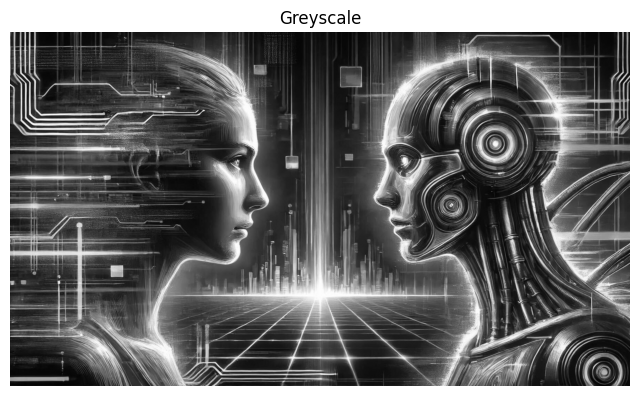

In [22]:
# converting colored image to greyscale
plt.figure(figsize=(8,6))
plt.imshow(gray, cmap='gray')
plt.title('Greyscale')
plt.axis('off')
plt.show()

In [29]:
!pip install ultralytics

In [30]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

In [33]:
# Download the model weights directly to ensure it's available
!wget -q https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11n.pt

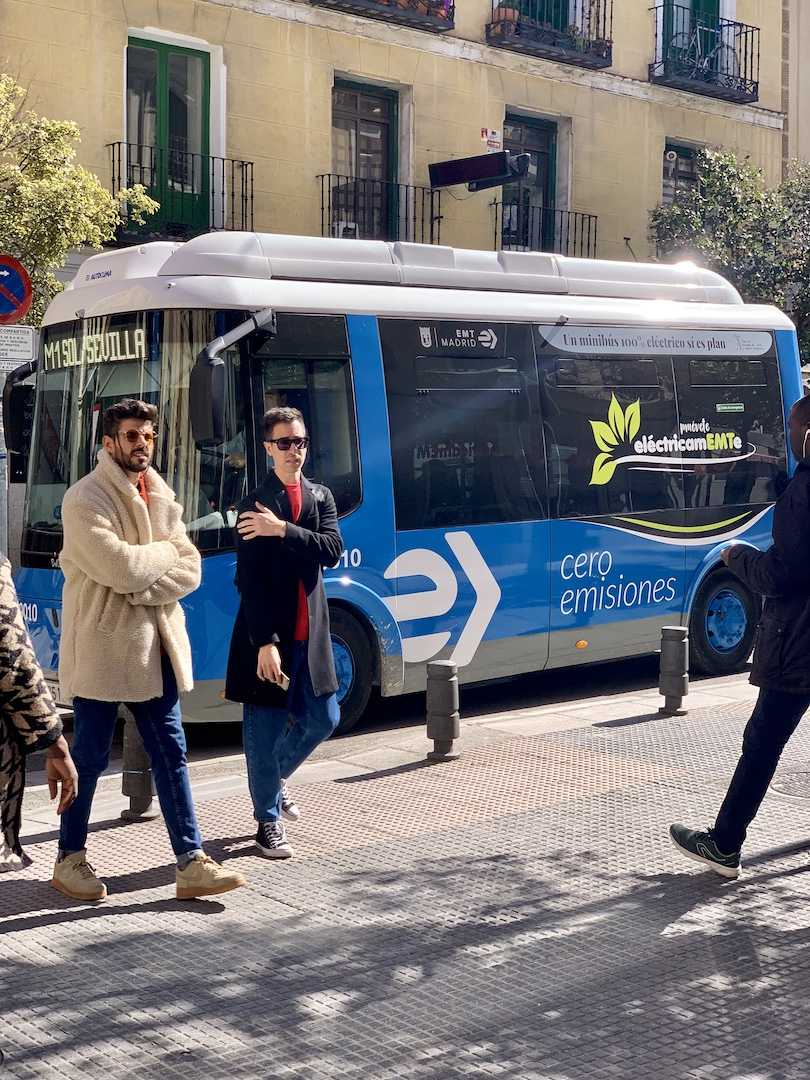

In [34]:
!wget -q https://ultralytics.com/images/bus.jpg -O sample_people.jpg
img = cv2.imread('sample_people.jpg')
cv2_imshow(img)

Number of people detected: 4


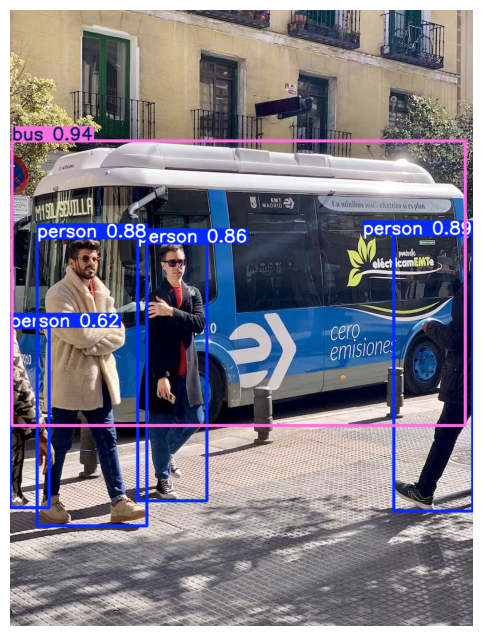

In [35]:
# Load YOLO11n from the downloaded file (fast & accurate)
model = YOLO("yolo11n.pt")

results = model('sample_people.jpg', verbose=False)[0]

# Count only people (class 0 = person in COCO dataset)
person_count = sum(1 for cls in results.boxes.cls if int(cls) == 0)

print(f"Number of people detected: {person_count}")

# Show image with bounding boxes
plt.figure(figsize=(12,8))
plt.imshow(results.plot()[:,:,::-1])  # Convert BGR to RGB
plt.axis('off')
plt.show()